In [1]:
from strategies import *
from scipy.signal import savgol_filter
import pandas as pd
import sqlite3 as sq3

if __name__ == '__main__':
    
    df = pd.read_csv("../../backtesting/data/GOOGL/GOOGL.USUSD_Candlestick_5_M_ASK_05.10.2022-05.10.2024.csv")

    df['Gmt time']=df["Gmt time"].str.replace(".000","")
    df['Gmt time']=pd.to_datetime(df['Gmt time'],format='%d.%m.%Y %H:%M:%S')
    df['est']=pd.to_datetime(df["Gmt time"], unit='ms').dt.tz_localize('UTC').dt.tz_convert('US/Eastern')
    
    fromTodayStart = '2022-10-05 09:30:00'
    toNow   = '2023-10-05 16:00:00'
    df = df[df['est'].between(fromTodayStart, toNow)].copy()

    df.rename(columns={"Open": "open"}, inplace=True)
    df.rename(columns={"High": "high"}, inplace=True)
    df.rename(columns={"Low": "low"}, inplace=True)
    df.rename(columns={"Volume": "volume"}, inplace=True)
    df.rename(columns={"Close": "close"}, inplace=True)
    
    df=df[df.notnull().all(axis=1)]
    df=df[(df.volume != 0)]
    df=df[df.high!=df.low]
    
    df.reset_index(drop=True, inplace=True)
    df['bar']=df.index
    
    df = df[['est','bar','high','low','close','volume','open']] 

    result = squeez(df).copy()
    #result.to_csv('trading_result.csv', index=False)

In [2]:
def positionArea(x):
    extraSpace = 1.20
    if (x['position']==POSITION['LONG'].value):
        return x['low']-extraSpace
    elif (x['position']==POSITION['SHORT'].value):
        return x['high']+extraSpace    
    else:
        return np.nan
        
def posibleEntryArea(x):
    extraSpace = 1
    if (x['posible_entry']==POSITION['LONG'].value):
        return x['low']-extraSpace
    elif (x['posible_entry']==POSITION['SHORT'].value):
        return x['high']+extraSpace    
    else:
        return np.nan
                
def squeezeCloseToEmaArea(x):
    extraSpace = .80
    if (x['squeeze_close_ema']==EMA25['PRICE_ACCION_OVER_EMA'].value):
        return x['low']-extraSpace
    elif (x['squeeze_close_ema']==EMA25['PRICE_ACCION_UNDER_EMA'].value):
        return x['high']+extraSpace
    else:
        return np.nan
        
def squezzeArea(x):
    extraSpace = .50
    if (x['squeezed_area']==EMA25['PRICE_ACCION_OVER_EMA'].value):
        return x['low']-extraSpace
    elif (x['squeezed_area']==EMA25['PRICE_ACCION_UNDER_EMA'].value):
        return x['high']+extraSpace
    else:
        return np.nan
        
with pd.option_context("mode.copy_on_write", True): 
    result['squezzeArea'] = result.apply(lambda row: squezzeArea(row), axis=1)
    result['squeezeCloseToEmaArea'] = result.apply(lambda row: squeezeCloseToEmaArea(row), axis=1)
    result['posibleEntry'] = result.apply(lambda row: posibleEntryArea(row), axis=1)
    result['positionArea'] = result.apply(lambda row: positionArea(row), axis=1)

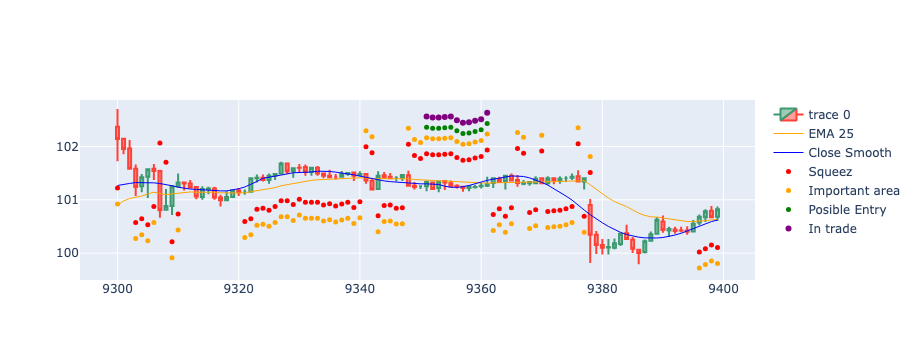

In [10]:
import plotly.io as pio
import plotly.graph_objects as go  

dfpl = result[9300:9400]

fig = go.Figure(
    data=[
        go.Candlestick(
            x=dfpl['bar'], 
            open=dfpl['open'],
            high=dfpl['high'],
            low=dfpl['low'],
            close=dfpl['close']),
        go.Scatter(
            x=dfpl['bar'], 
            y=dfpl['ema25'],
            line=dict(color='orange', width=1), 
            name="EMA 25"),
        go.Scatter(
            x=dfpl['bar'], 
            y=dfpl['close_smooth'],
            line=dict(color='blue', width=1), 
            name="Close Smooth")
    ]
)

fig.add_scatter(x=dfpl['bar'], y=dfpl['squezzeArea'], mode="markers", marker=dict(size=5, color="red"), name="Squeez")
fig.add_scatter(x=dfpl['bar'], y=dfpl['squeezeCloseToEmaArea'], mode="markers", marker=dict(size=5, color="orange"), name="Important area")
fig.add_scatter(x=dfpl['bar'], y=dfpl['posibleEntry'], mode="markers", marker=dict(size=5, color="green"), name="Posible Entry")
fig.add_scatter(x=dfpl['bar'], y=dfpl['positionArea'], mode="markers", marker=dict(size=6, color="purple"), name="In trade")

fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()

In [1]:
from strategies import *
from scipy.signal import savgol_filter
import pandas as pd
import sqlite3 as sq3

if __name__ == '__main__':
    
    df = pd.read_csv("../../backtesting/data/GOOGL/GOOGL.USUSD_Candlestick_5_M_ASK_05.10.2022-05.10.2024.csv")

    df['Gmt time']=df["Gmt time"].str.replace(".000","")
    df['Gmt time']=pd.to_datetime(df['Gmt time'],format='%d.%m.%Y %H:%M:%S')
    df['est']=pd.to_datetime(df["Gmt time"], unit='ms').dt.tz_localize('UTC').dt.tz_convert('US/Eastern')
    
    fromTodayStart = '2022-10-05 09:30:00'
    toNow   = '2023-10-05 16:00:00'
    df = df[df['est'].between(fromTodayStart, toNow)].copy()

    df.rename(columns={"Open": "open"}, inplace=True)
    df.rename(columns={"High": "high"}, inplace=True)
    df.rename(columns={"Low": "low"}, inplace=True)
    df.rename(columns={"Volume": "volume"}, inplace=True)
    df.rename(columns={"Close": "close"}, inplace=True)
    
    df=df[df.notnull().all(axis=1)]
    df=df[(df.volume != 0)]
    df=df[df.high!=df.low]
    
    df.reset_index(drop=True, inplace=True)
    df['bar']=df.index
    
    df = df[['est','bar','high','low','close','volume','open']] 

    result = squeez(df).copy()
    #result.to_csv('trading_result.csv', index=False)
    
    conn = sq3.connect('squeez_rawdata_v2.sql') 
    result.to_sql('data', conn, if_exists='append')

    print(result)

         bar  symbol    date_est  time_est     high      low    close  volume  \
0          0  GOOGLE  2022-10-05  09:30:00  100.384   99.783  100.364  2.4060   
1          1  GOOGLE  2022-10-05  09:35:00  100.394   99.743  100.014  2.3076   
2          2  GOOGLE  2022-10-05  09:40:00  100.014   99.563   99.584  2.0172   
3          3  GOOGLE  2022-10-05  09:45:00  100.023   99.563   99.873  2.2860   
4          4  GOOGLE  2022-10-05  09:50:00   99.973   99.463   99.533  2.3784   
...      ...     ...         ...       ...      ...      ...      ...     ...   
19555  19555  GOOGLE  2023-10-05  15:35:00  135.224  135.103  135.163  0.7200   
19556  19556  GOOGLE  2023-10-05  15:40:00  135.213  135.084  135.113  0.7068   
19557  19557  GOOGLE  2023-10-05  15:45:00  135.224  134.973  135.193  0.8016   
19558  19558  GOOGLE  2023-10-05  15:50:00  135.254  134.983  135.164  0.9396   
19559  19559  GOOGLE  2023-10-05  15:55:00  135.174  134.974  135.083  1.0968   

          open  close_smoot

In [ ]:
from strategies import *
from scipy.signal import savgol_filter
import pandas as pd
import sqlite3 as sq3

if __name__ == '__main__':
    
    df = pd.read_csv("../../backtesting/data/GOOGL/GOOGL.USUSD_Candlestick_5_M_ASK_05.10.2022-05.10.2024.csv")

    df['Gmt time']=df["Gmt time"].str.replace(".000","")
    df['Gmt time']=pd.to_datetime(df['Gmt time'],format='%d.%m.%Y %H:%M:%S')
    datetime_est=pd.to_datetime(df["Gmt time"], unit='ms').dt.tz_localize('UTC').dt.tz_convert('US/Eastern')
    
    fromTodayStart = '2022-10-05 09:30:00'
    toNow   = '2022-12-05 16:00:00'
    df = df[datetime_est.between(fromTodayStart, toNow)].copy()

    df.rename(columns={"Open": "open"}, inplace=True)
    df.rename(columns={"High": "high"}, inplace=True)
    df.rename(columns={"Low": "low"}, inplace=True)
    df.rename(columns={"Volume": "volume"}, inplace=True)
    df.rename(columns={"Close": "close"}, inplace=True)
    df.rename(columns={"Gmt time": "time"}, inplace=True)

    df=df[df.notnull().all(axis=1)]
    df=df[(df.volume != 0)]
    df=df[df.high!=df.low]
    
    df.reset_index(drop=True, inplace=True)
    df['index']=df.index
    
    df.set_index("time", inplace=True, drop=True)
    
    df = df[['index','high','low','close','volume','open']] 

    result = squeez(df).copy()
    result = result.sort_values(by=['index'],ascending = True)
    
    log_sequence = []
    
    for candle in range(0, len(result)):

        if candle < 100:
            continue

        position = (result.iloc[candle]).position
        date = (result.iloc[candle]).date_est
        time = (result.iloc[candle]).time_est
        qty = (result.iloc[candle]).qty
        price = (result.iloc[candle]).price
        close = (result.iloc[candle]).close

        if (position==1):
            trans = [date, time, candle, 'GOOGLE', qty, round(price, 2), 'B']
        elif (position==-1):  
            trans = [date, time, candle, 'GOOGLE', qty, round(price, 2), 'S']
        else:
            prevPos = (result.iloc[candle-1]).position
            if prevPos==1:
                 trans = [date, time, candle, 'GOOGLE', qty, round(close, 2), 'SELL_LONG']
            elif prevPos==-1:
                trans = [date, time, candle, 'GOOGLE', qty, round(close, 2), 'BUY_SHORT']
                
    
    df_log_sequence = df_log_sequence.sort_values(by=['Candle'],ascending = True)
    df_log_sequence.to_csv('trading_result.csv', index=False)
    
    #conn = sq3.connect('trading_vow.sql') 
    #df_log_sequence.to_sql('data', conn, if_exists='append')